## notebook for waelet coherence

In [11]:
import numpy as np
import xarray as xr
import os

import pycwt #  as wavelet
# from pycwt.helpers import find

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors

import cmocean as cmo
import palettable.colorbrewer as cb 

from process_raw_data import process_data, decimal_year_to_datetime 
from stats_plots import plot_timeseries

In [12]:
SAVING = True 
ds = xr.open_dataset("data/Bayesian_estimates_Atlantic_MHT_HTC_HF_OHC.nc")
ds["time"] = decimal_year_to_datetime(ds.time.values)

mht = ds.mht.isel(lat=slice(1,None)).dropna(dim="time", how="any") # drop 65

mht_mean = mht.mean(dim="posterior_samples")

# detrend , mean removed
mht_detrended_anom = process_data(mht_mean, detrended=True).dropna(dim="time", how="any")

# pycwt already accounts for mean and std!
# mht_std = mht_detrended_anom.std(dim="time")
# mht_norm = mht_detrended_anom / mht_std

## check normality

In [69]:
# lat_idx = 1
# data = mht_mean.isel(lat=lat_idx).to_numpy()

# plt.hist(data, bins=15, color="steelblue", edgecolor="white")
# plt.title(f"Histogram at lat index {lat_idx}")
# plt.xlabel("MHT")
# plt.ylabel("Count")
# plt.show()

In [13]:
lats = ds.latitude.values
lat_labels = [f"{np.abs(lat)}{'°N' if lat > 0 else '°S'}" for lat in lats]

lats = lats[1:]  # drop 65
lat_labels = lat_labels[1:]  # drop 65
n_lats = len(lats)


In [87]:
plt.rcParams.update({
    # axes
    'axes.titlesize'  : 18,
    'axes.labelsize'  : 18,
    # ticks
    'xtick.labelsize' : 15,
    'ytick.labelsize' : 15,
    # legend
    'legend.fontsize' : 14,
    'legend.title_fontsize': 14,
    # colorbar
    'figure.titlesize': 20,
})

In [88]:
# cmap_sel = plt.cm.Greens

# cmap = mcolors.ListedColormap(cmap_sel(np.linspace(0.5, 1, 40)))

# plot_timeseries(
#     data={
#         # "raw": mht_mean,
#         # "detrended anom":  mht_detrended_anom,
#         "normalized ( / std per lat)": mht_norm,
#     },
#     lats=[-5.0],
#     all_lats=lats,
#     labels=lat_labels,
#     cmap=cmap,
#     anomalies=False,
#     xbase=4,
#     ylabel="MHT (std normalized)"
# )

## latitude pairs: 16°N - 5°N , where break happens

In [136]:
idx_5 = [np.where((lats == 5))[0][0]]
idx_5S = [np.where((lats == -5))[0][0]]
idx_16 = [np.where((lats == 16))[0][0]]
mht_5_pd = mht_detrended_anom.isel(lat=idx_5).to_numpy()[0]
mht_5S_pd = mht_detrended_anom.isel(lat=idx_5S).to_numpy()[0]
mht_16_pd = mht_detrended_anom.isel(lat=idx_16).to_numpy()[0]

## latitude pairs 26°N and 11°S, in the middle of each block

In [17]:
idx_26 = [np.where((lats == 26))[0][0]]
idx_11S = [np.where((lats == -11))[0][0]]
idx_25S = [np.where((lats == -25))[0][0]]
mht_26_pd = mht_detrended_anom.isel(lat=idx_26).to_numpy()[0]
mht_11S_pd = mht_detrended_anom.isel(lat=idx_11S).to_numpy()[0]
mht_25S_pd = mht_detrended_anom.isel(lat=idx_25S).to_numpy()[0]


time = mht.time.values

In [130]:
def wct_analysis(
    y1, y2, 
    time, 
    sig=True, 
    normalize=True,
    ):
    
    N = len(time) # all have the same time
    dt = 0.25
    s0 = 2 * dt
    dj = 1 / 12

    J = int(1/dj * np.log2(N * dt / s0)) 
    
    WCT, arrowsWCT, COI, freq, sig = pycwt.wct(
        y1=y1,
        y2=y2,
        dt=dt,
        dj=dj,
        s0=s0,
        J=J,
        sig=sig,
        normalize=normalize, # default : true, normalized with STD!
        cache=False
    )
    
    period = 1 / freq

    return WCT, arrowsWCT, COI, period, sig
    
    
def wct_plot(
    WCT, arrowsWCT, COI, period, sig,
    time, 
    cmap=plt.cm.jet,
    title="26°N and 11°S",
    savefig=False,
    savelabel="cwt_26_11S"
    ):
        
    fig, ax  = plt.subplots(figsize=(8, 6))

    cf = ax.pcolormesh(time, period, WCT, cmap=cmap, shading='auto', vmin=0, vmax=1)
    fig.colorbar(cf, label='Coherence')

    ax.plot(time, COI, 'k--', linewidth=1.5)
    ax.fill_between(time, COI, period.max(), color='white', alpha=0.6, zorder=5)

    # significance contour (sig=1 marks 95% significance boundary)
    # 
    sig_2d = np.ones_like(WCT) * sig[:, np.newaxis]  # broadcast to (scales, time)
    # shading the NOT significant part:
    sig_ratio = WCT / sig_2d
    # Shade non-significant regions (ratio < 1) 
    sig_shading = ax.contourf(time, period, sig_ratio, levels=[0, 1], colors='None', hatches=['//'])
    sig_shading.set_edgecolor('white')
    sig_shading.set_linewidth(0)
        
    # ax.contourf(time, period, sig_ratio, levels=[0, 1], colors='white', alpha=0.4)
    ax.contour(time, period, sig_ratio, [1], colors='white', linewidths=1.5, label="Sig. 95%")
    
    # phase arrows (subsample so arrows aren't too dense)
    skip_t = 3
    skip_p = 3
    # sliciing the time and period and arrows , ::step
    # quiver doesnt take angle directly but x and y direction
    # x = cos(angle), y ( sin(angle) )
    ax.quiver(time[::skip_t], period[::skip_p],
            np.cos(arrowsWCT)[::skip_p, ::skip_t], np.sin(arrowsWCT)[::skip_p, ::skip_t],
            scale=30, width=0.003)

    ax.set_yscale('log', base=2)
    ax.set_ylim(period.min(), period.max())
    print(period.max())
    ax.invert_yaxis()  # short periods on top, like the book figure

    # change ticks to be not 2^0 but 1
    yticks = 2 ** np.arange(np.floor(np.log2(period.min())), np.ceil(np.log2(period.max())))
    ax.set_yticks(yticks)
    ax.set_yticklabels([f'{int(y)}' if y >= 1 else f'{y:.2f}' for y in yticks])
    ax.yaxis.set_minor_locator(plt.NullLocator())  # removes minor tick clutter

    ax.xaxis.set_major_locator(mdates.YearLocator(base=2))        # tick only at each year
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # show only the year number
        
    ax.set_xlabel('Time')
    ax.set_ylabel('Period (years)')
    ax.set_title(f"{title}")
    
    # plt.grid("grey", linestyle="--", alpha=0.5)

    if savefig:
        os.makedirs("figures/wct/", exist_ok=True)
        plt.savefig(f"figures/wct/{savelabel}.png", dpi=300, bbox_inches='tight')
    plt.show()
    

## first compute WCT for all pairs, just run once, takes some time, then do analysis = False and plot

## 26°N and 11°S

16.52869836398806


/var/folders/8k/45q47bzd1bxgf8pbps6hbstr0000gn/T/ipykernel_1197/2962418958.py:60: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(time, period, sig_ratio, [1], colors='white', linewidths=1.5, label="Sig. 95%")


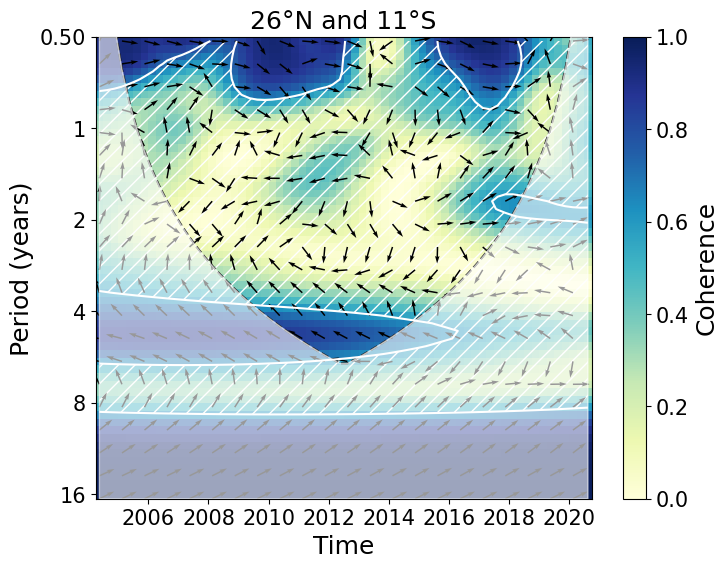

In [131]:
do_analysis = False
if do_analysis:
    WCT, arrowsWCT, COI, period, sig = wct_analysis(
        mht_26_pd,
        mht_11S_pd,
        time=time
    )

cmap = cb.sequential.YlGnBu_9.mpl_colormap
# cmap = "viridis"
wct_plot(
   WCT, arrowsWCT, COI, period, sig,
   time=time,
   cmap=cmap,
   savefig=True,
   savelabel="26_11S"
#    title="" 
)


## 26°N and 25°S

16.52869836398806


/var/folders/8k/45q47bzd1bxgf8pbps6hbstr0000gn/T/ipykernel_1197/2962418958.py:60: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(time, period, sig_ratio, [1], colors='white', linewidths=1.5, label="Sig. 95%")


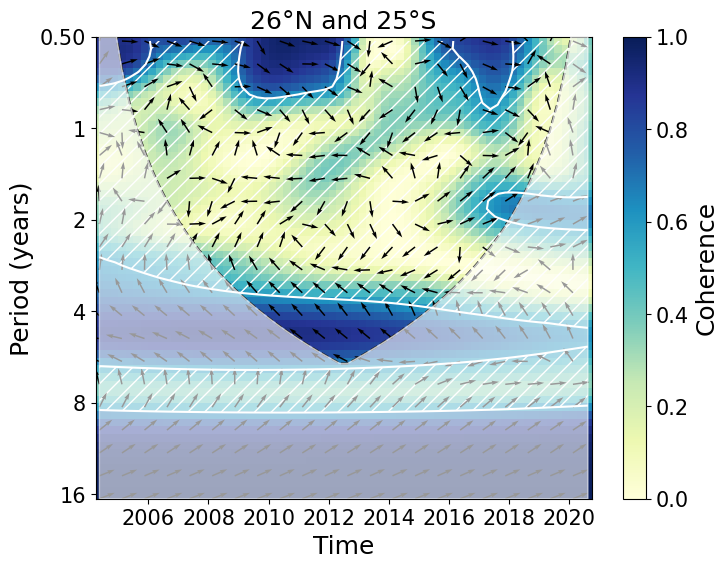

In [132]:
if do_analysis:
    WCT_2625S, arrowsWCT_2625S, COI_2625S, period_2625S, sig_2625S = wct_analysis(
        mht_26_pd,
        mht_25S_pd,
        time=time
    )
    
wct_plot(
    WCT_2625S, arrowsWCT_2625S, COI_2625S, period_2625S, sig_2625S,
    time=time,
    cmap=cmap,
    title="26°N and 25°S",
    savefig=True,
    savelabel="26_25S"
)

## 16°N and 5°N

16.52869836398806


/var/folders/8k/45q47bzd1bxgf8pbps6hbstr0000gn/T/ipykernel_1197/2962418958.py:60: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(time, period, sig_ratio, [1], colors='white', linewidths=1.5, label="Sig. 95%")


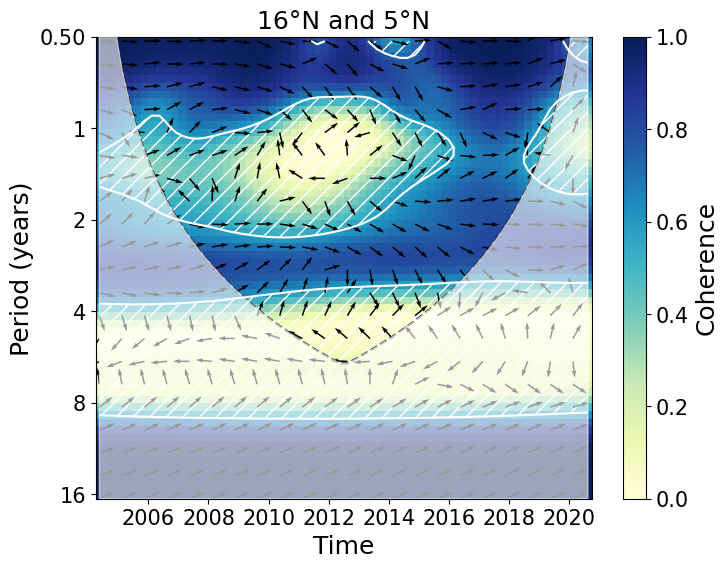

In [133]:
if do_analysis:
    WCT_165, arrowsWCT_165, COI__165, period_165, sig_165 = wct_analysis(
        mht_16_pd,
        mht_5_pd,
        time=time
    )
    
wct_plot(
    WCT_165, arrowsWCT_165, COI__165, period_165, sig_165,
    time=time,
    cmap=cmap,
    title="16°N and 5°N",
    savefig=True,
    savelabel="16_5N"
)

## 16°N and 5°S

Calculating wavelet coherence significance


100%|██████████| 300/300 [00:13<00:00, 22.99it/s]
/var/folders/8k/45q47bzd1bxgf8pbps6hbstr0000gn/T/ipykernel_1197/2962418958.py:60: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(time, period, sig_ratio, [1], colors='white', linewidths=1.5, label="Sig. 95%")


16.52869836398806


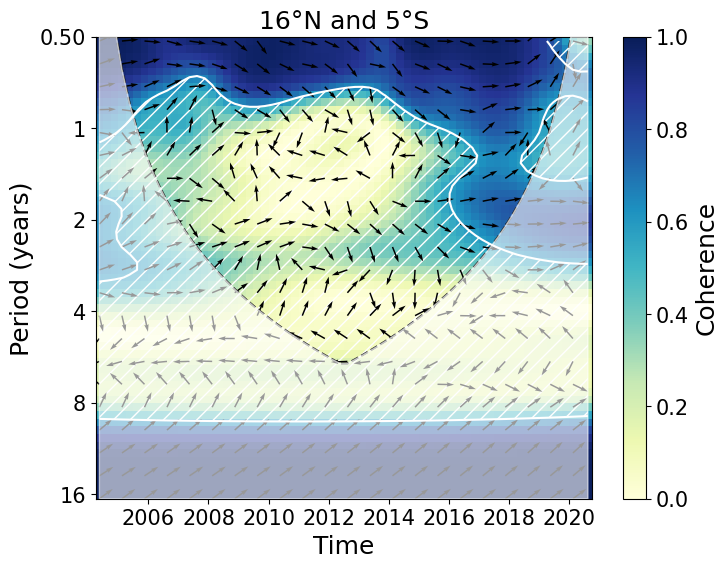

In [137]:
if do_analysis:
    WCT_165S, arrowsWCT_165S, COI_165S, period_165S, sig_165S = wct_analysis(
        mht_16_pd,
        mht_5S_pd,
        time=time
    )
    
wct_plot(
    WCT_165S, arrowsWCT_165S, COI_165S, period_165S, sig_165S,
    time=time,
    cmap=cmap,
    title="16°N and 5°S",
    savefig=True,
    savelabel="16N_5S"
)

## 35°N and 35°S

In [134]:
idx_35 = [np.where((lats == 35))[0][0]]
mht_35_pd = mht_detrended_anom.isel(lat=idx_35).to_numpy()[0]

idx_35S = [np.where((lats == -35))[0][0]]
mht_35S_pd = mht_detrended_anom.isel(lat=idx_35S).to_numpy()[0]


16.52869836398806


/var/folders/8k/45q47bzd1bxgf8pbps6hbstr0000gn/T/ipykernel_1197/2962418958.py:60: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(time, period, sig_ratio, [1], colors='white', linewidths=1.5, label="Sig. 95%")


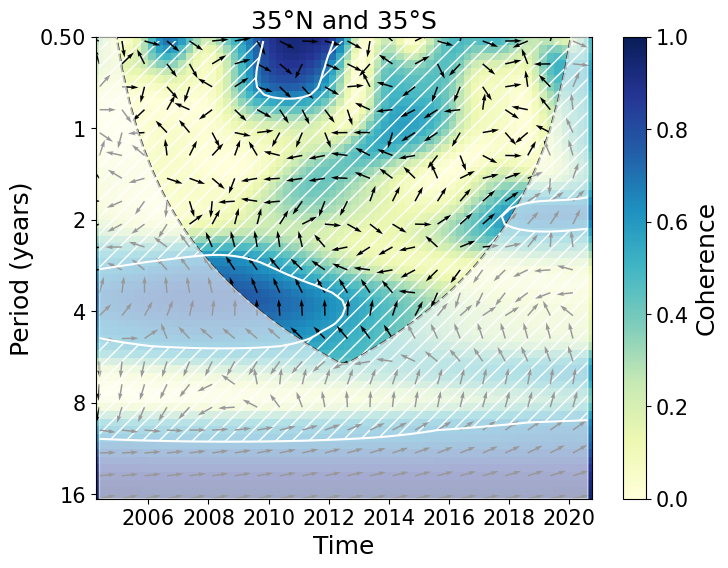

In [135]:

if do_analysis:
    WCT_35, arrowsWCT_35, COI_35, period_35, sig_35 = wct_analysis(
        mht_35_pd,
        mht_35S_pd,
        time=time
    )
    
wct_plot(
    WCT_35, arrowsWCT_35, COI_35, period_35, sig_35,
    time=time,
    cmap=cmap,
    title="35°N and 35°S",
    savefig=True,
    savelabel="35S_35N"
)